# Calibration vs Adjudicated Affinity Confusion Matrix

This notebook compares calibration labels against adjudicated RA labels for the same `(Abstract_Index, RA2025_ID)` pairs.

- Calibration source: `calibration_abstract_question_affinities.csv`
- Adjudicated source: `adjudicated_ra_affinities.csv`

The adjudicated `Final_Affinity` score is mapped to `Low` / `Moderate` / `High` using the same thresholds as the project adjudication code.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [10]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
calibration_root = repo_root / "data" / "results" / "affinity_calibration"
benchmark_root = repo_root / "data" / "results" / "affinity_benchmark"

calibration_run_dir_names = ["20260618_Mark_batch1_v2"]
benchmark_run_dir_names = ["20260422_212121_1", "20260422_212121_4","20260422_212121_3"]
# benchmark_run_dir_names = ["20260422_212121_1"]
calibration_input_filename = "calibration_abstract_question_affinities.csv"
benchmark_input_filename = "adjudicated_ra_affinities.csv"

LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
NUM_TO_LABEL = {0: "Low", 1: "Moderate", 2: "High"}

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def infer_column(columns, preferred, fallback=None):
    if preferred in columns:
        return preferred
    lower_map = {str(col).strip().lower(): col for col in columns}
    for name in fallback or []:
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

def normalize_level(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        text = value.strip().lower()
        if text in {"low", "moderate", "high"}:
            return text.capitalize()
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        score = float(value)
        if 0 <= score <= 40:
            return "Low"
        if 40 < score <= 70:
            return "Moderate"
        if 70 < score <= 100:
            return "High"

    return np.nan

In [11]:
calibration_frames, selected_calibration_dirs = collect_frames(
    calibration_root, calibration_run_dir_names, calibration_input_filename, "calibration"
)
benchmark_frames, selected_benchmark_dirs = collect_frames(
    benchmark_root, benchmark_run_dir_names, benchmark_input_filename, "benchmark"
)

calib_df = pd.concat(calibration_frames, ignore_index=True)
bench_df = pd.concat(benchmark_frames, ignore_index=True)

merged_df = pd.merge(
    calib_df,
    bench_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_calib", "_bench"),
)

calibration_label_col = infer_column(merged_df.columns, "Evaluator_Affinity_Level", ["evaluator_affinity_level"])
benchmark_score_col = infer_column(merged_df.columns, "Final_Affinity", ["final_affinity"])

if calibration_label_col is None:
    raise ValueError("Could not find calibration label column 'Evaluator_Affinity_Level'.")
if benchmark_score_col is None:
    raise ValueError("Could not find benchmark score column 'Final_Affinity'.")

merged_df["calibration_level"] = merged_df[calibration_label_col].apply(normalize_level)
merged_df["benchmark_level"] = merged_df[benchmark_score_col].apply(normalize_level)
clean_df = merged_df.dropna(subset=["calibration_level", "benchmark_level"]).copy()
clean_df["calibration_num"] = clean_df["calibration_level"].map(LABEL_TO_NUM).astype(int)
clean_df["benchmark_num"] = clean_df["benchmark_level"].map(LABEL_TO_NUM).astype(int)

print("Calibration run directories:", [p.name for p in selected_calibration_dirs])
print("Benchmark run directories:", [p.name for p in selected_benchmark_dirs])
print("Calibration rows loaded:", len(calib_df))
print("Benchmark rows loaded:", len(bench_df))
print("Rows after inner merge:", len(merged_df))
print("Rows after label cleaning:", len(clean_df))
print("Calibration label distribution:")
display(clean_df["calibration_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
print("Benchmark label distribution:")
display(clean_df["benchmark_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
display(clean_df[["Abstract_Index", "RA2025_ID", calibration_label_col, benchmark_score_col, "calibration_level", "benchmark_level"]].head(10))

Calibration run directories: ['20260618_Mark_batch1_v2']
Benchmark run directories: ['20260422_212121_1', '20260422_212121_3', '20260422_212121_4']
Calibration rows loaded: 118
Benchmark rows loaded: 14400
Rows after inner merge: 118
Rows after label cleaning: 118
Calibration label distribution:


,count
calibration_level,
Low,55
Moderate,62
High,1


Benchmark label distribution:


,count
benchmark_level,
Low,48
Moderate,33
High,37


,Abstract_Index,RA2025_ID,Evaluator_Affinity_Level,Final_Affinity,calibration_level,benchmark_level
0,1,23,Low,33.000000,Low,Low
1,1,24,Moderate,41.000000,Moderate,Moderate
2,1,27,Moderate,58.000000,Moderate,Moderate
3,1,35,Low,28.000000,Low,Low
4,1,37,Moderate,39.000000,Moderate,Low
5,1,39,Low,31.000000,Low,Low
6,1,41,Moderate,87.333333,Moderate,High
7,1,42,Moderate,81.000000,Moderate,High
8,1,43,Moderate,38.000000,Moderate,Low
9,1,47,Low,39.000000,Low,Low


,Adjudicated Low,Adjudicated Moderate,Adjudicated High
Calibration Low,36,12,7
Calibration Moderate,12,21,29
Calibration High,0,0,1


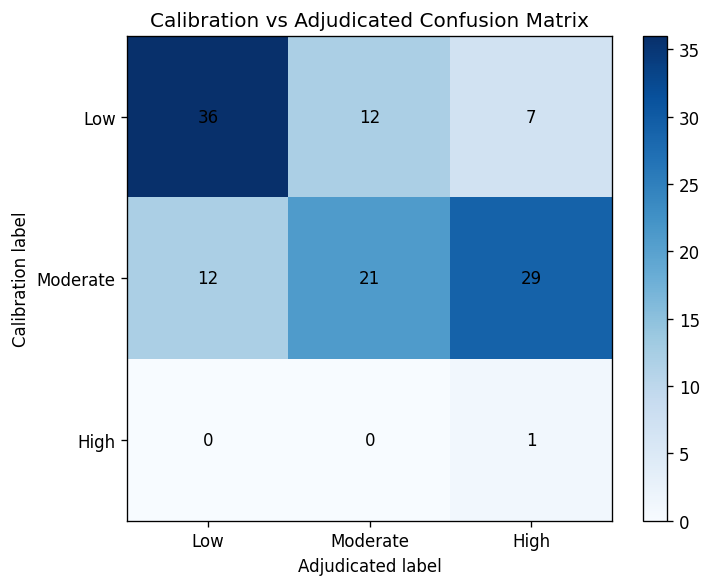

In [12]:
y_true = clean_df["calibration_num"].to_numpy()
y_pred = clean_df["benchmark_num"].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=[f"Calibration {label}" for label in LABEL_ORDER],
    columns=[f"Adjudicated {label}" for label in LABEL_ORDER],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(LABEL_ORDER)
ax.set_yticklabels(LABEL_ORDER)
ax.set_xlabel("Adjudicated label")
ax.set_ylabel("Calibration label")
ax.set_title("Calibration vs Adjudicated Confusion Matrix")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Notes

If you want to compare a different benchmark run, change `benchmark_run_dir_names` in the setup cell. The confusion matrix uses the shared ordinal bins `Low`, `Moderate`, and `High`.